# Telco Customer Churn — Exploratory Data Analysis (EDA)

This notebook explores the cleaned Telco Customer Churn dataset to uncover
patterns, relationships, and churn drivers. The goal is to understand the
data before modeling and identify meaningful business insights.

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("../data/cleaned/cleaned_telco_churn.csv")

df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   int64  
 4   Dependents        7032 non-null   int64  
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   int64  
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   int64  


,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn
count,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,0.482509,0.298493,32.421786,0.903299,0.592719,64.798208,2283.300441,0.265785
std,0.368844,0.499729,0.457629,24.545260,0.295571,0.491363,30.085974,2266.771362,0.441782
min,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,18.250000,18.800000,0.000000
25%,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,35.587500,401.450000,0.000000
50%,0.000000,0.000000,0.000000,29.000000,1.000000,1.000000,70.350000,1397.475000,0.000000
75%,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,89.862500,3794.737500,1.000000
max,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,118.750000,8684.800000,1.000000


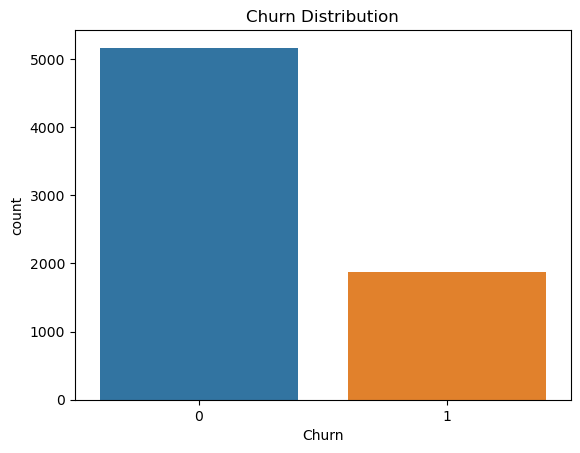

Churn
0    0.734215
1    0.265785
Name: proportion, dtype: float64

In [3]:
# Churn Distribution
sns.countplot(data=df, x='Churn')
plt.title("Churn Distribution")
plt.show()

df['Churn'].value_counts(normalize=True)

C:\Users\rober\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


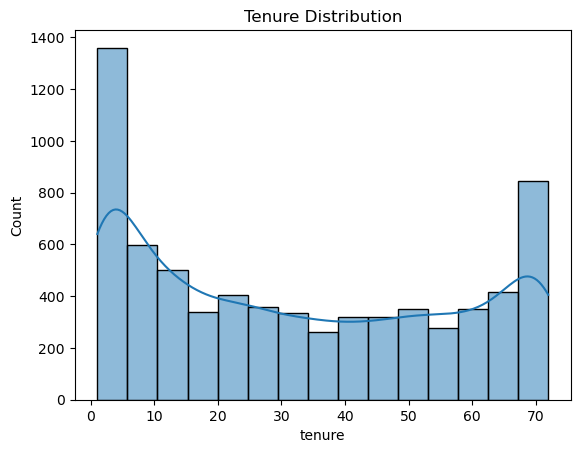

In [4]:
# Tenure Distribution
sns.histplot(df['tenure'], kde=True)
plt.title("Tenure Distribution")
plt.show()

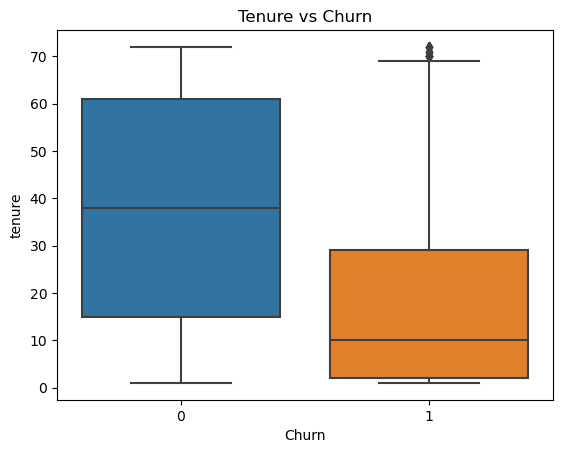

In [5]:
# Tenure vs Churn
sns.boxplot(data=df, x='Churn', y='tenure')
plt.title("Tenure vs Churn")
plt.show()

C:\Users\rober\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


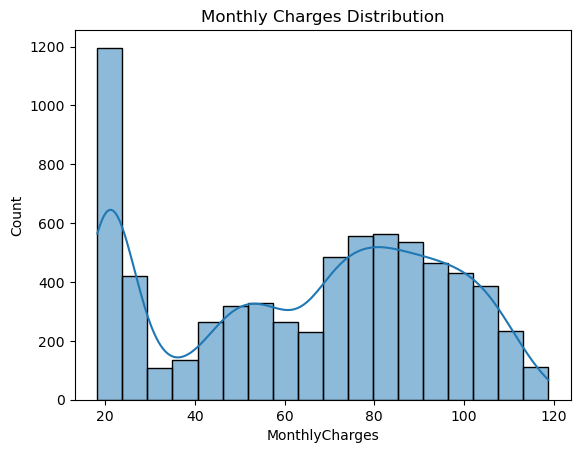

In [6]:
# Monthly Charge Distribution
sns.histplot(df['MonthlyCharges'], kde=True)
plt.title("Monthly Charges Distribution")
plt.show()

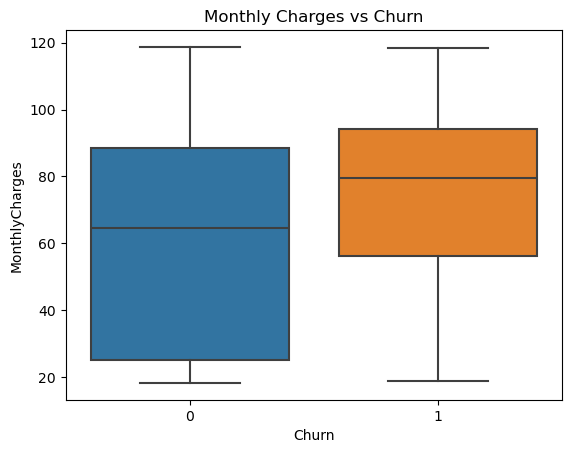

In [7]:
# Monthly Charge vs Churn
sns.boxplot(data=df, x='Churn', y='MonthlyCharges')
plt.title("Monthly Charges vs Churn")
plt.show()

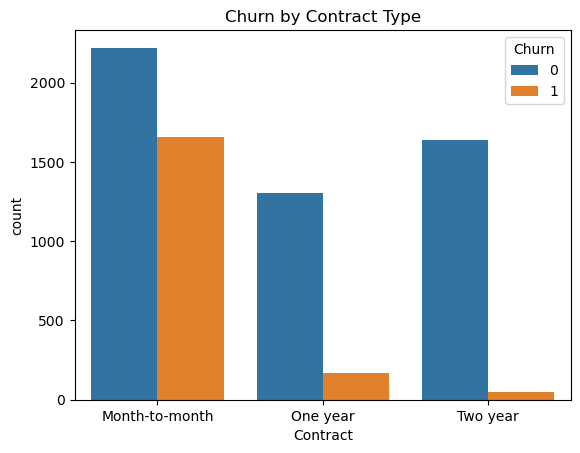

In [8]:
# Contract Type vs Churn
sns.countplot(data=df, x='Contract', hue=df['Churn'].astype(str))
plt.title("Churn by Contract Type")
plt.show()

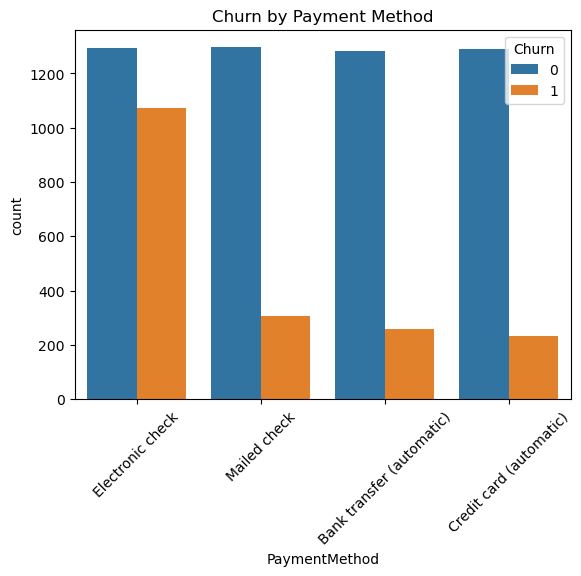

In [9]:
# Payment Method vs Churn
sns.countplot(data=df, x='PaymentMethod', hue=df['Churn'].astype(str))
plt.xticks(rotation=45)
plt.title("Churn by Payment Method")
plt.show()

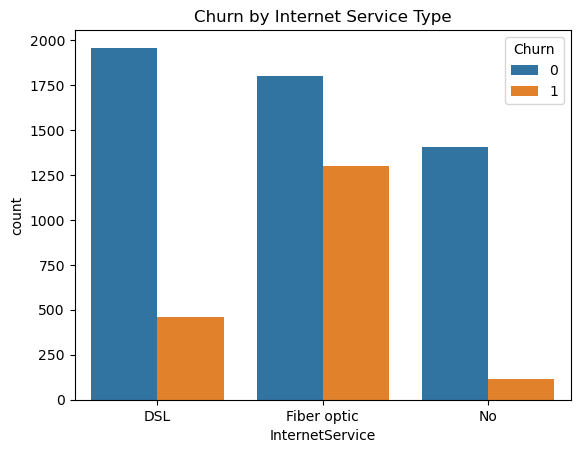

In [10]:
# Internet Service vs Churn
sns.countplot(data=df, x='InternetService', hue=df['Churn'].astype(str))
plt.title("Churn by Internet Service Type")
plt.show()

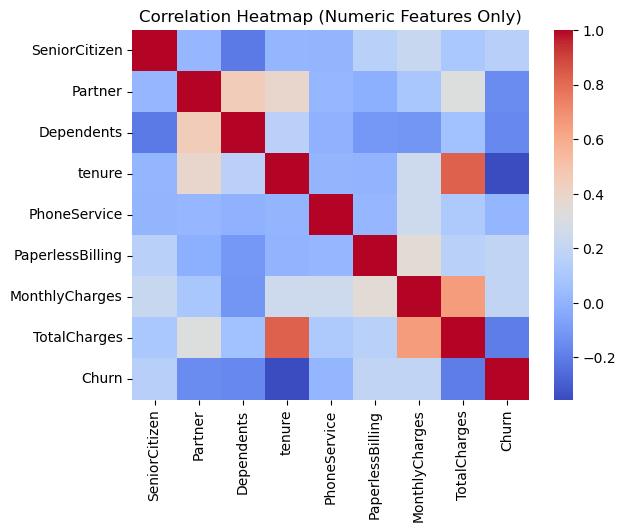

In [11]:
# Correlation Heatmap for Numeric Features
numeric_df = df.select_dtypes(include=['int64','float64'])
sns.heatmap(numeric_df.corr(), annot=False, cmap='coolwarm')
plt.title("Correlation Heatmap (Numeric Features Only)")
plt.show()

In [12]:
# Export
df.to_csv("../data/cleaned/eda_ready_telco_churn.csv", index=False)

# Summary

Key churn drivers identified:
- Low tenure strongly increases churn
- Month-to-month contracts have highest churn
- Electronic check users churn more frequently
- Higher monthly charges correlate with churn
- Fiber optic customers churn more than DSL customers

These insights will guide feature engineering, modeling, and dashboard design.